# Init

In [1]:
import os, pickle
from random import choice
from collections import deque

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
_DATA_DRIVE = "DATA_TANK"

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

In [3]:
fldrs = [ f"/media/james/{_DATA_DRIVE}/2025-08B_{test}" for test in tests ]
paths = deque()
for fldr in fldrs:
    paths.extend( [os.path.join( fldr, item ) for item in os.listdir( path = fldr ) if "pkl" in item ] )
fPath = choice( paths )
data = list()
with open( fPath, 'rb' ) as f:
    data = pickle.load( f )

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# Read File

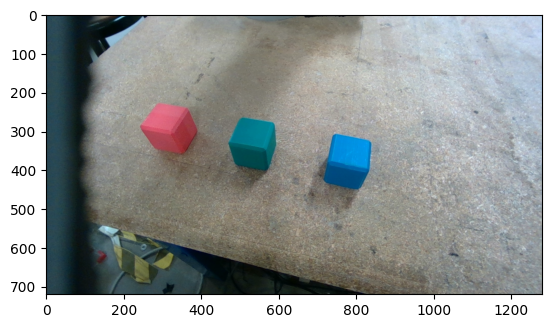

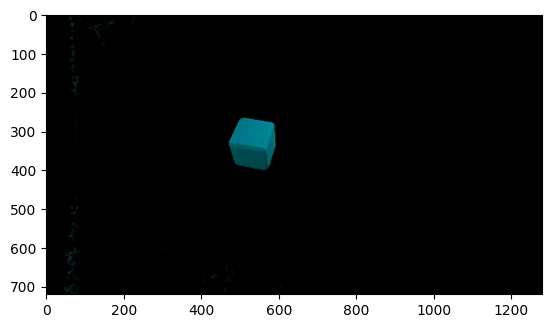

In [4]:
for i, datum in enumerate( data ):
    tMsg  = datum['msg']
    tData = datum['data']
    if tMsg == "ObsMeta":
        inpt = tData['input']
        hits = tData['hits']
        imag = inpt[ choice( list( inpt.keys() ) ) ]['image']
        plt.figure()
        plt.imshow( imag )

        # Convert BGR to HSV
        hsv_image = cv2.cvtColor(imag, cv2.COLOR_RGB2HSV)
        
        # lower = np.array([85, 100, 100])  # Example: lower bound for RED
        # upper = np.array([255, 255, 255]) # Example: upper bound for RED

        # lower = np.array([200/2,150,37]) # Example: lower bound for BLUE
        # upper = np.array([255/2,255,255]) # Example: upper bound for BLUE

        lower = np.array([80/2,150,15]) # Example: lower bound for GREEN
        upper = np.array([190/2,255,255]) # Example: upper bound for GREEN

        # Create a mask for blue color
        mask = cv2.inRange( hsv_image, lower, upper)
        
        # Optional: Apply the mask to the original image to show only the blue object
        result = cv2.bitwise_and( imag, imag, mask = mask )
        plt.figure()
        plt.imshow( result )
        # plt.imshow( mask )

        
        break